In [1]:
import platform
import sklearn

print(platform.system())
if platform.system()== 'Windows':
    sklearn.set_config(display='text')

Windows


In [2]:
import matplotlib.pyplot as plt

# OS에 따른 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')  # 윈도우: 맑은 고딕
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')    # 맥: 애플 고딕
else:
    plt.rc('font', family='NanumBarunGothic') # 리눅스

# 마이너스 기호 깨짐 방지
plt.rc('axes', unicode_minus=False)

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.spatial.distance import pdist

In [ ]:
data = np.array(
    [
        [1.0, 0.9, 0.0, 0.0],  # 데이터 0 (A그룹 유사)
        [0.8, 1.0, 0.1, 0.0],  # 데이터 1 (A그룹 유사)
        [0.1, 0.0, 0.9, 1.0],  # 데이터 2 (B그룹 유사)
        [0.0, 0.2, 0.8, 0.9],  # 데이터 3 (B그룹 유사)
        [0.5, 0.5, 0.5, 0.5],  # 데이터 4 (중간 특성)
    ]
)

# metric='cosine'을 지정하여 코사인 거리를 계산합니다.
# 코사인 거리 = 1 - 코사인 유사도
#pdist( ) : i<j 상삼각 행렬의 원소를 의미한다.
distance_matrix = pdist(data, metric="cosine")
print(f'distance_matrix={distance_matrix}')

distance_matrix=[0.0162887  0.94490337 0.89039255 0.29387056 0.90189949 0.82142407
 0.260426   0.01624674 0.25875068 0.22172968]


In [7]:
from scipy.spatial.distance import pdist, squareform

# 1D 10개 배열 -> 2D 5x5 행렬로 변환
full_matrix = squareform(distance_matrix)
print(full_matrix)

[[0.         0.0162887  0.94490337 0.89039255 0.29387056]
 [0.0162887  0.         0.90189949 0.82142407 0.260426  ]
 [0.94490337 0.90189949 0.         0.01624674 0.25875068]
 [0.89039255 0.82142407 0.01624674 0.         0.22172968]
 [0.29387056 0.260426   0.25875068 0.22172968 0.        ]]


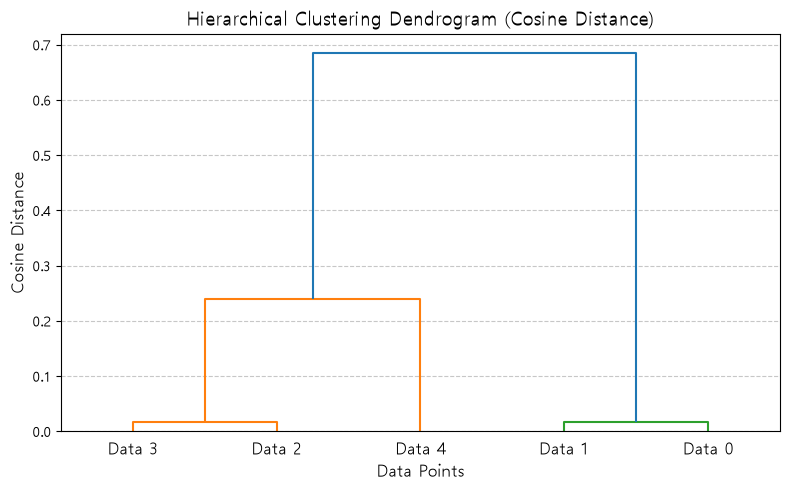

clusters[1 1 2 2 2]
--- 군집화 결과 ---
Data 0 -> Cluster 1
Data 1 -> Cluster 1
Data 2 -> Cluster 2
Data 3 -> Cluster 2
Data 4 -> Cluster 2


In [16]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN, KMeans
from sklearn.datasets import make_moons
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler
# 1. 샘플 데이터 생성 (5개의 문서 또는 아이템의 특징 벡터)
# 코사인 거리는 방향성이 중요하므로 스파스(Sparse)하거나 고차원 특성 벡터에 유용합니다.
data = np.array(
    [
        [1.0, 0.9, 0.0, 0.0],  # 데이터 0 (A그룹 유사)
        [0.8, 1.0, 0.1, 0.0],  # 데이터 1 (A그룹 유사)
        [0.1, 0.0, 0.9, 1.0],  # 데이터 2 (B그룹 유사)
        [0.0, 0.2, 0.8, 0.9],  # 데이터 3 (B그룹 유사)
        [0.5, 0.5, 0.5, 0.5],  # 데이터 4 (중간 특성)
    ]
)

labels = ["Data 0", "Data 1", "Data 2", "Data 3", "Data 4"]

# 2. 코사인 거리 행렬(Distance Matrix) 계산
# metric='cosine'을 지정하여 코사인 거리를 계산합니다.
# 코사인 거리 = 1 - 코사인 유사도
distance_matrix = pdist(data, metric="cosine")

# 3. 계층적 군집화 수행 (Linkage 계산)
# 와드(Ward)법은 유클리드 거리만 지원하므로,
# 코사인 거리 사용 시 'average', 'complete', 'single' 등의 연결법을 사용합니다.
Z = linkage(distance_matrix, method="average")

# 4. 덴드로그램 시각화
plt.figure(figsize=(8, 5))
dendrogram(Z, labels=labels, orientation="top", distance_sort="descending")

plt.title("Hierarchical Clustering Dendrogram (Cosine Distance)", fontsize=14)
plt.xlabel("Data Points", fontsize=12)
plt.ylabel("Cosine Distance", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# 5. 특정 거리 임계값(Threshold) 또는 군집 수 기준으로 클러스터 라벨 추출
# 예: 코사인 거리가 0.5 이하인 것끼리 묶기
max_d = 0.5
clusters = fcluster(Z, criterion="distance", t=max_d)
print(f'clusters{clusters}')

print("--- 군집화 결과 ---")
for label, cluster_id in zip(labels, clusters):
    print(f"{label} -> Cluster {cluster_id}")

distance_matrix=[0.18049208 1.37470242 1.3344606  0.76664276 1.34305584 1.28173638
 0.72170077 0.18025946 0.71937568 0.66592744]
Z:
[[2.         3.         0.18025946 2.        ]
 [0.         1.         0.18049208 2.        ]
 [4.         5.         0.79360527 3.        ]
 [6.         7.         1.73374314 5.        ]]


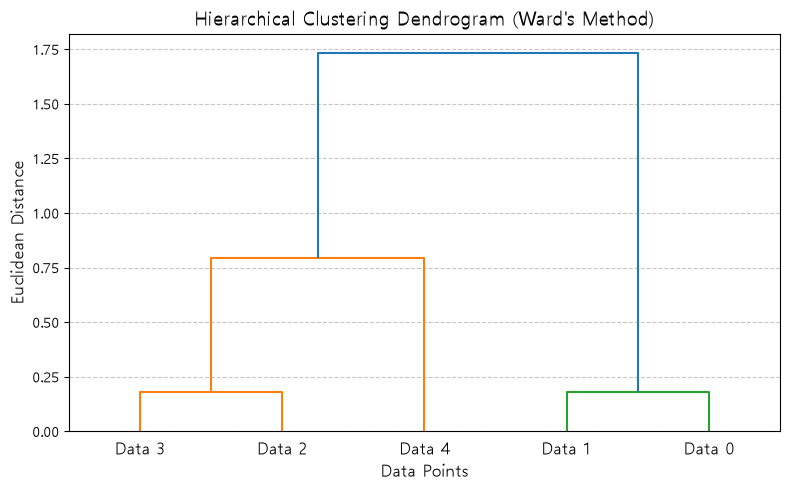

--- 군집화 결과 ---
Data 0 -> Cluster 1
Data 1 -> Cluster 1
Data 2 -> Cluster 2
Data 3 -> Cluster 2
Data 4 -> Cluster 2


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist
# 1. 샘플 데이터 생성
data = np.array(
[
[1.0, 0.9, 0.0, 0.0],  # 데이터 0 (A그룹 유사)
[0.8, 1.0, 0.1, 0.0],  # 데이터 1 (A그룹 유사)
[0.1, 0.0, 0.9, 1.0],  # 데이터 2 (B그룹 유사)
[0.0, 0.2, 0.8, 0.9],  # 데이터 3 (B그룹 유사)
[0.5, 0.5, 0.5, 0.5],  # 데이터 4 (중간 특성)
]
)
labels = ["Data 0", "Data 1", "Data 2", "Data 3", "Data 4"]
# 2. 코사인 특성 유지를 위한 L2 정규화 (각 행 벡터의 크기를 1로 맞춤)
# 정규화된 데이터의 유클리드 거리는 코사인 거리와 단조 비례 관계를 가집니다.
data_norm = data / np.linalg.norm(data, axis=1, keepdims=True)
# 3. 유클리드 거리 행렬 계산 (metric='euclidean')
distance_matrix = pdist(data_norm, metric="euclidean")
print(f'distance_matrix={distance_matrix}')
# 4. 계층적 군집화 수행 (와드 연결법 method="ward")
Z = linkage(distance_matrix, method="ward")
print(f'Z:\n{Z}')
# 5. 덴드로그램 시각화
plt.figure(figsize=(8, 5))
dendrogram(Z, labels=labels, orientation="top", distance_sort="descending")
plt.title("Hierarchical Clustering Dendrogram (Ward's Method)", fontsize=14)
plt.xlabel("Data Points", fontsize=12)
plt.ylabel("Euclidean Distance", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()
# 6. 임계값(Threshold) 기준 클러스터 라벨 추출
max_d = 0.8
clusters = fcluster(Z, criterion="distance", t=max_d)
print("--- 군집화 결과 ---")
for label, cluster_id in zip(labels, clusters):
    print(f"{label} -> Cluster {cluster_id}")